# Notebook: Redes Neuronales Convolucionales (CNN) para HAM10000

Este cuaderno mantiene la **misma secuencia general del ejemplo del profesor**:

1. Introducción a CNN.
2. Preparación del entorno.
3. Carga y visualización del dataset.
4. DataLoaders y dispositivo.
5. CNN entrenada desde cero.
6. Data Augmentation.
7. Transfer Learning con ResNet18.
8. Grad-CAM.
9. Buenas prácticas.
10. Guardado de modelos.
11. Ejercicios sugeridos desarrollados.

La adaptación se realiza con el dataset **HAM10000**, usando solamente:

- **0 = Nevus (`nv`)**
- **1 = Melanoma (`mel`)**

Además, se incorporan las observaciones del segundo ejemplo:

- Gráficas de **Train Loss y Validation Loss**.
- Gráficas de **Accuracy y ROC-AUC**.
- Comparaciones entre experimentos.
- Evolución del **Learning Rate**.
- Matrices de confusión.
- Fine-tuning.
- Calibración de probabilidades.
- Curvas ROC.
- Grad-CAM corregido.

Los entrenamientos se realizan con **30 épocas**. En Transfer Learning se usan
**15 épocas en Stage 1 + 15 épocas en Stage 2 = 30 épocas totales**.

> Este trabajo es académico y no representa un sistema de diagnóstico médico.

## 1. ¿Qué es una CNN y por qué se usa en imágenes?

Una **CNN (Convolutional Neural Network)** es una red neuronal diseñada para trabajar con imágenes.

Las CNN aprenden patrones visuales mediante filtros que detectan bordes, texturas, formas y características más complejas.

### 1.1. Componentes principales

**Convolución**
- Extrae características de las imágenes.

**ReLU**
- Introduce no linealidad.

**Pooling**
- Reduce el tamaño de los mapas de características.

**Capas fully-connected**
- Utilizan las características aprendidas para realizar la clasificación.

En este trabajo la CNN aprenderá a diferenciar imágenes de **Nevus** y **Melanoma**.

## 2. Preparación del entorno

Usaremos **PyTorch**, `kagglehub`, NumPy, Matplotlib y scikit-learn.

### Antes de ejecutar

En Google Colab se recomienda activar GPU:

**Entorno de ejecución → Cambiar tipo de entorno de ejecución → T4 GPU**

Después puede usarse **Entorno de ejecución → Ejecutar todo**.

Debido a que los ejercicios entrenan varios modelos durante 30 épocas,
la ejecución completa puede tardar bastante. Es normal.

In [1]:
# Instalamos las librerías necesarias
!pip install -q kagglehub

In [2]:
# Librerías básicas
import os
import random
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Imágenes
from PIL import Image

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models

# Métricas y división de datos
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

# Barra de progreso y descarga de dataset
from tqdm import tqdm
import kagglehub

## 3. Cargar el dataset médico (HAM10000)

HAM10000 contiene imágenes dermatoscópicas de lesiones de piel.

Para este trabajo usaremos solo dos clases:

- `nv` = Nevus
- `mel` = Melanoma

Esto mantiene el problema como una clasificación binaria.

In [3]:
# Fijamos una semilla para obtener resultados más reproducibles
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Descargar HAM10000
path = kagglehub.dataset_download(
    "kmader/skin-cancer-mnist-ham10000"
)

print("Ruta:", path)

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Ruta: /kaggle/input/skin-cancer-mnist-ham10000


In [4]:
# Leemos los metadatos del dataset
metadata_path = os.path.join(
    path,
    "HAM10000_metadata.csv"
)

df = pd.read_csv(metadata_path)

# Usamos solo Nevus y Melanoma
df_binary = df[
    df["dx"].isin(["nv", "mel"])
].copy()

# Convertimos las clases a números
# 0 = Nevus
# 1 = Melanoma
df_binary["label"] = df_binary["dx"].map({
    "nv": 0,
    "mel": 1
})

df_binary["class_name"] = df_binary["dx"].map({
    "nv": "Nevus",
    "mel": "Melanoma"
})

print(df_binary["class_name"].value_counts())
print("Total:", len(df_binary))

class_name
Nevus       6705
Melanoma    1113
Name: count, dtype: int64
Total: 7818


In [5]:
# Verificamos que las dos clases estén presentes
assert set(df_binary["label"].unique()) == {0, 1}

print("\nClases utilizadas:")
print("0 = Nevus")
print("1 = Melanoma")


Clases utilizadas:
0 = Nevus
1 = Melanoma


In [6]:
# Buscamos automáticamente las rutas de todas las imágenes
image_paths = {}

for root, dirs, files in os.walk(path):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            image_id = os.path.splitext(file)[0]
            image_paths[image_id] = os.path.join(root, file)

# Relacionamos cada image_id con su archivo
df_binary["path"] = df_binary["image_id"].map(image_paths)

print(
    "Imágenes sin encontrar:",
    df_binary["path"].isna().sum()
)

Imágenes sin encontrar: 0


In [7]:
# Separamos los datos por lesion_id para evitar que imágenes
# de la misma lesión aparezcan en entrenamiento y prueba
gss1 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.30,
    random_state=SEED
)

train_idx, temp_idx = next(
    gss1.split(
        df_binary,
        groups=df_binary["lesion_id"]
    )
)

train_df = df_binary.iloc[
    train_idx
].reset_index(drop=True)

temp_df = df_binary.iloc[
    temp_idx
].reset_index(drop=True)

# Dividimos el 30 % restante en validación y prueba
gss2 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.50,
    random_state=SEED
)

val_idx, test_idx = next(
    gss2.split(
        temp_df,
        groups=temp_df["lesion_id"]
    )
)

val_df = temp_df.iloc[
    val_idx
].reset_index(drop=True)

test_df = temp_df.iloc[
    test_idx
].reset_index(drop=True)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

Train: 5465
Val: 1205
Test: 1148


In [8]:
# Revisamos la cantidad de cada clase en cada subconjunto
print("\nDistribución TRAIN")
print(train_df["class_name"].value_counts())

print("\nDistribución VALIDATION")
print(val_df["class_name"].value_counts())

print("\nDistribución TEST")
print(test_df["class_name"].value_counts())


Distribución TRAIN
class_name
Nevus       4686
Melanoma     779
Name: count, dtype: int64

Distribución VALIDATION
class_name
Nevus       1015
Melanoma     190
Name: count, dtype: int64

Distribución TEST
class_name
Nevus       1004
Melanoma     144
Name: count, dtype: int64


In [9]:
# Clase para que PyTorch pueda leer las imágenes
class HAMDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None
    ):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        image = Image.open(
            row["path"]
        ).convert("RGB")

        label = int(row["label"])

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(
            label,
            dtype=torch.long
        )

In [10]:
# Transformación básica
transform_basic = T.Compose([
    T.Resize((128, 128)),
    T.ToTensor()
])

train_dataset = HAMDataset(
    train_df,
    transform=transform_basic
)

val_dataset = HAMDataset(
    val_df,
    transform=transform_basic
)

test_dataset = HAMDataset(
    test_df,
    transform=transform_basic
)

len(train_dataset), len(val_dataset), len(test_dataset)

(5465, 1205, 1148)

### 3.1. Visualizar ejemplos

Antes de entrenar es útil observar ejemplos del dataset.

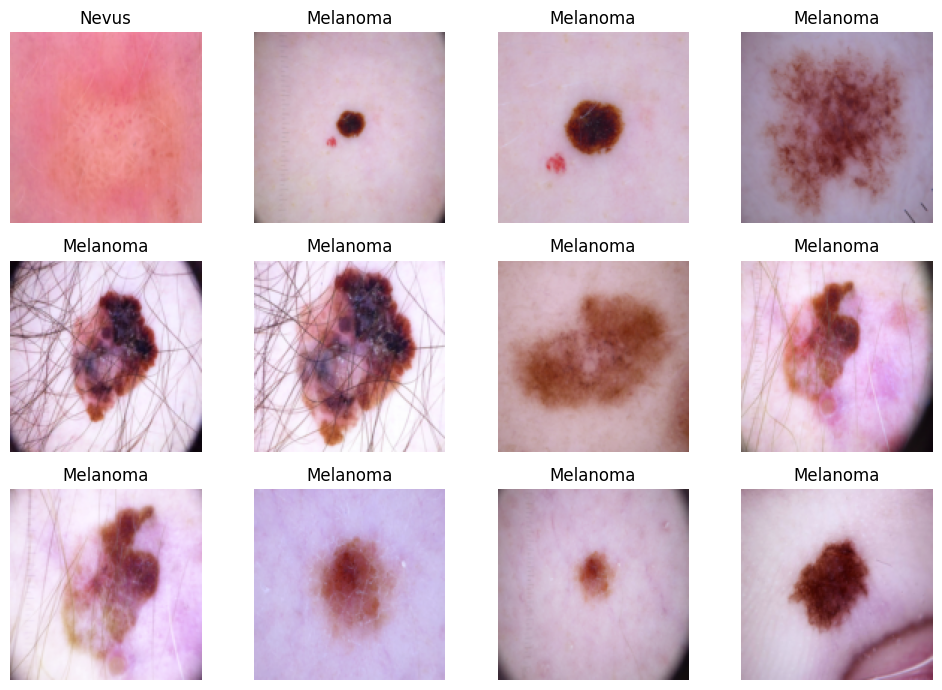

In [11]:
# Mostramos ejemplos de ambas clases
def show_batch(dataset, n=12):

    plt.figure(figsize=(10, 7))

    for i in range(n):

        x, y = dataset[i]

        plt.subplot(3, 4, i + 1)

        # PyTorch usa C,H,W y Matplotlib usa H,W,C
        img = x.permute(1, 2, 0).numpy()

        plt.imshow(img)

        clase = (
            "Melanoma"
            if int(y.item()) == 1
            else "Nevus"
        )

        plt.title(clase)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_batch(train_dataset, n=12)

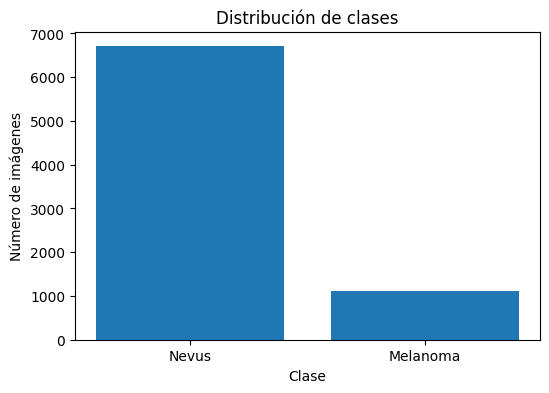

In [12]:
# Distribución de las dos clases
conteo = df_binary["class_name"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(conteo.index, conteo.values)
plt.title("Distribución de clases")
plt.xlabel("Clase")
plt.ylabel("Número de imágenes")
plt.show()

## 4. Preparar DataLoaders y device

Los DataLoaders organizan las imágenes en lotes.  
El `device` permite usar GPU cuando está disponible.

In [13]:
# Usamos GPU si está disponible
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

device

device(type='cuda')

In [14]:
# Tamaño del lote
batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

next(iter(train_loader))[0].shape, next(iter(train_loader))[1].shape

(torch.Size([64, 3, 128, 128]), torch.Size([64]))

## 5. Modelo 1: CNN entrenada desde cero

Construiremos una CNN sencilla siguiendo el mismo patrón del ejemplo del profesor:

- Convolución
- ReLU
- Pooling
- Clasificador final

In [15]:
# Número de clases
num_classes = 2

# CNN simple
class SimpleCNN(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                3,
                16,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                16,
                32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),

            # Dejamos un mapa de 1 x 1 por canal
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(
                64,
                num_classes
            )
        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x

model_scratch = SimpleCNN(
    num_classes=num_classes
).to(device)

model_scratch

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=64, out_features=2, bias=True)
  )
)

### 5.1. Funciones de entrenamiento y evaluación

Usaremos:

- Accuracy
- ROC-AUC
- Matriz de confusión
- Precision, Recall y F1

In [16]:
# Convierte logits en probabilidad de la clase positiva (Melanoma)
def logits_to_probs(logits):

    return torch.softmax(
        logits,
        dim=1
    )[:, 1]


# Evaluación
@torch.no_grad()
def evaluate(
    model,
    loader,
    criterion=None
):

    model.eval()

    all_labels = []
    all_probs = []
    all_preds = []

    losses = []

    for x, y in loader:

        x = x.to(device)
        y = y.to(device).long()

        logits = model(x)

        if criterion is not None:
            loss = criterion(
                logits,
                y
            )
            losses.append(
                loss.item()
            )

        probs = logits_to_probs(
            logits
        )

        preds = (
            probs >= 0.5
        ).long()

        all_labels.append(
            y.cpu().numpy()
        )

        all_probs.append(
            probs.cpu().numpy()
        )

        all_preds.append(
            preds.cpu().numpy()
        )

    y_true = np.concatenate(
        all_labels
    )

    y_prob = np.concatenate(
        all_probs
    )

    y_pred = np.concatenate(
        all_preds
    )

    acc = accuracy_score(
        y_true,
        y_pred
    )

    auc = roc_auc_score(
        y_true,
        y_prob
    )

    avg_loss = (
        float(np.mean(losses))
        if len(losses) > 0
        else None
    )

    return (
        acc,
        auc,
        y_true,
        y_pred,
        y_prob,
        avg_loss
    )


# Entrenamiento de una época
def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion
):

    model.train()

    losses = []

    for x, y in loader:

        x = x.to(device)
        y = y.to(device).long()

        optimizer.zero_grad()

        logits = model(x)

        loss = criterion(
            logits,
            y
        )

        loss.backward()

        optimizer.step()

        losses.append(
            loss.item()
        )

    return float(
        np.mean(losses)
    )

### 5.2. Entrenar el modelo desde cero

En este trabajo entrenaremos durante **30 épocas**.

In [17]:
# Como existe desbalance entre clases,
# usamos pesos en la función de pérdida
counts = train_df[
    "label"
].value_counts().sort_index()

class_weights = (
    len(train_df)
    / (2 * counts.values)
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

print("Pesos de clase:", class_weights)

Pesos de clase: tensor([0.5831, 3.5077], device='cuda:0')


In [18]:
# Función de pérdida y optimizador
criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

optimizer = torch.optim.Adam(
    model_scratch.parameters(),
    lr=1e-3
)

# 30 épocas
epochs = 30

history_scratch = {
    "train_loss": [],
    "val_loss": [],
    "val_acc": [],
    "val_auc": []
}

for epoch in range(
    1,
    epochs + 1
):

    # Entrenamiento
    train_loss = train_one_epoch(
        model_scratch,
        train_loader,
        optimizer,
        criterion
    )

    # Validación
    (
        val_acc,
        val_auc,
        _,
        _,
        _,
        val_loss
    ) = evaluate(
        model_scratch,
        val_loader,
        criterion
    )

    history_scratch[
        "train_loss"
    ].append(train_loss)

    history_scratch[
        "val_loss"
    ].append(val_loss)

    history_scratch[
        "val_acc"
    ].append(val_acc)

    history_scratch[
        "val_auc"
    ].append(val_auc)

    print(
        f"Epoch {epoch:02d}/30 | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_auc={val_auc:.4f}"
    )

Epoch 01/30 | train_loss=0.6281 | val_loss=0.5703 | val_acc=0.6083 | val_auc=0.7412
Epoch 02/30 | train_loss=0.5194 | val_loss=0.5619 | val_acc=0.5851 | val_auc=0.7842
Epoch 03/30 | train_loss=0.5100 | val_loss=0.4843 | val_acc=0.6174 | val_auc=0.7866
Epoch 04/30 | train_loss=0.4896 | val_loss=0.5152 | val_acc=0.6299 | val_auc=0.7974
Epoch 05/30 | train_loss=0.4914 | val_loss=0.5192 | val_acc=0.6083 | val_auc=0.8147
Epoch 06/30 | train_loss=0.4994 | val_loss=0.5162 | val_acc=0.6183 | val_auc=0.8170
Epoch 07/30 | train_loss=0.4882 | val_loss=0.5130 | val_acc=0.6448 | val_auc=0.8079
Epoch 08/30 | train_loss=0.4801 | val_loss=0.4949 | val_acc=0.6672 | val_auc=0.8079
Epoch 09/30 | train_loss=0.4856 | val_loss=0.5251 | val_acc=0.6506 | val_auc=0.8162
Epoch 10/30 | train_loss=0.4793 | val_loss=0.4817 | val_acc=0.6697 | val_auc=0.8147
Epoch 11/30 | train_loss=0.4708 | val_loss=0.5105 | val_acc=0.6614 | val_auc=0.8160
Epoch 12/30 | train_loss=0.4720 | val_loss=0.4989 | val_acc=0.6622 | val_auc

### 5.3. Curvas de entrenamiento

Estas gráficas siguen el estilo del ejemplo del profesor.

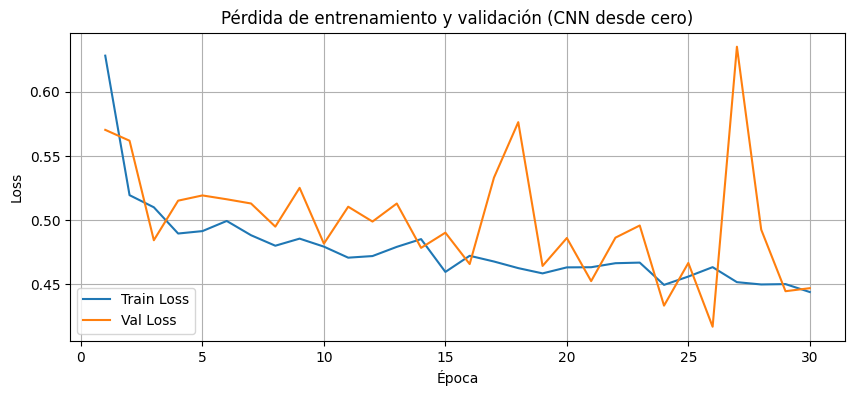

In [19]:
# Pérdida de entrenamiento y validación
epocas = range(
    1,
    epochs + 1
)

plt.figure(figsize=(10, 4))

plt.plot(
    epocas,
    history_scratch["train_loss"],
    label="Train Loss"
)

plt.plot(
    epocas,
    history_scratch["val_loss"],
    label="Val Loss"
)

plt.title(
    "Pérdida de entrenamiento y validación (CNN desde cero)"
)

plt.xlabel("Época")
plt.ylabel("Loss")

plt.legend()
plt.grid()
plt.show()

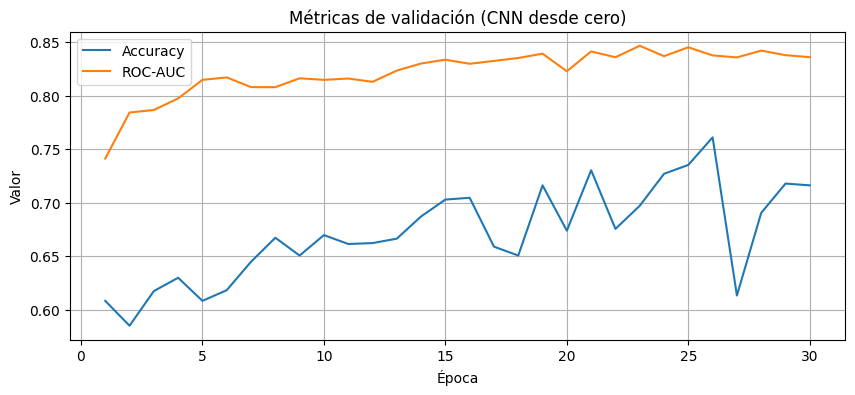

In [20]:
# Accuracy y ROC-AUC de validación
plt.figure(figsize=(10, 4))

plt.plot(
    epocas,
    history_scratch["val_acc"],
    label="Accuracy"
)

plt.plot(
    epocas,
    history_scratch["val_auc"],
    label="ROC-AUC"
)

plt.title(
    "Métricas de validación (CNN desde cero)"
)

plt.xlabel("Época")
plt.ylabel("Valor")

plt.legend()
plt.grid()
plt.show()

### 5.4. Evaluación final en test

In [21]:
(
    test_acc,
    test_auc,
    y_true,
    y_pred,
    y_prob,
    test_loss
) = evaluate(
    model_scratch,
    test_loader,
    criterion
)

print(
    f"Test accuracy: {test_acc:.4f}"
)

print(
    f"Test ROC-AUC: {test_auc:.4f}"
)

print()

print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "Nevus",
            "Melanoma"
        ],
        digits=4
    )
)

cm = confusion_matrix(
    y_true,
    y_pred
)

cm

Test accuracy: 0.7439
Test ROC-AUC: 0.8475

              precision    recall  f1-score   support

       Nevus     0.9647    0.7341    0.8337      1004
    Melanoma     0.3047    0.8125    0.4432       144

    accuracy                         0.7439      1148
   macro avg     0.6347    0.7733    0.6384      1148
weighted avg     0.8819    0.7439    0.7847      1148



array([[737, 267],
       [ 27, 117]])

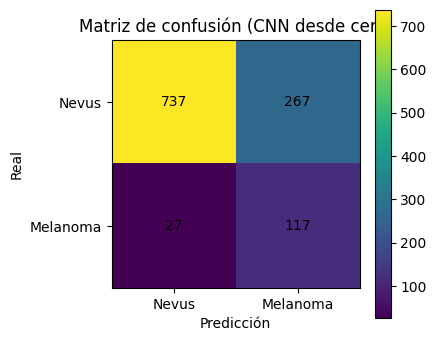

In [22]:
# Matriz de confusión
plt.figure(figsize=(4, 4))

plt.imshow(cm)

plt.title(
    "Matriz de confusión (CNN desde cero)"
)

plt.xlabel("Predicción")
plt.ylabel("Real")

plt.xticks(
    [0, 1],
    ["Nevus", "Melanoma"]
)

plt.yticks(
    [0, 1],
    ["Nevus", "Melanoma"]
)

for i in range(2):
    for j in range(2):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()

## 6. Data Augmentation (aumento de datos)

El aumento de datos crea variaciones de las imágenes durante el entrenamiento.

Para imágenes de piel usaremos transformaciones moderadas:

- Rotación pequeña.
- Traslación suave.
- Flip horizontal.

In [23]:
# Transformaciones con augmentation
transform_aug = T.Compose([

    T.Resize((128, 128)),

    T.RandomRotation(
        degrees=10
    ),

    T.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05)
    ),

    T.RandomHorizontalFlip(
        p=0.5
    ),

    T.ToTensor()
])

train_dataset_aug = HAMDataset(
    train_df,
    transform=transform_aug
)

train_loader_aug = DataLoader(
    train_dataset_aug,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

In [ ]:
# Nuevo modelo con la misma arquitectura
model_aug = SimpleCNN(
    num_classes=num_classes
).to(device)

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

optimizer = torch.optim.Adam(
    model_aug.parameters(),
    lr=1e-3
)

# 30 épocas
epochs_aug = 30

history_aug = {
    "train_loss": [],
    "val_loss": [],
    "val_acc": [],
    "val_auc": []
}

for epoch in range(
    1,
    epochs_aug + 1
):

    train_loss = train_one_epoch(
        model_aug,
        train_loader_aug,
        optimizer,
        criterion
    )

    (
        val_acc,
        val_auc,
        _,
        _,
        _,
        val_loss
    ) = evaluate(
        model_aug,
        val_loader,
        criterion
    )

    history_aug[
        "train_loss"
    ].append(train_loss)

    history_aug[
        "val_loss"
    ].append(val_loss)

    history_aug[
        "val_acc"
    ].append(val_acc)

    history_aug[
        "val_auc"
    ].append(val_auc)

    print(
        f"Epoch {epoch:02d}/30 | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_auc={val_auc:.4f}"
    )

Epoch 01/30 | train_loss=0.6736 | val_loss=0.7166 | val_acc=0.5660 | val_auc=0.7177
Epoch 02/30 | train_loss=0.5791 | val_loss=0.7350 | val_acc=0.4805 | val_auc=0.7509
Epoch 03/30 | train_loss=0.5568 | val_loss=0.5697 | val_acc=0.5867 | val_auc=0.7892
Epoch 04/30 | train_loss=0.5238 | val_loss=0.5379 | val_acc=0.5909 | val_auc=0.8054
Epoch 05/30 | train_loss=0.5040 | val_loss=0.4390 | val_acc=0.7012 | val_auc=0.7986
Epoch 06/30 | train_loss=0.4870 | val_loss=0.5264 | val_acc=0.6672 | val_auc=0.8074
Epoch 07/30 | train_loss=0.4873 | val_loss=0.4683 | val_acc=0.7112 | val_auc=0.8157
Epoch 08/30 | train_loss=0.4835 | val_loss=0.5700 | val_acc=0.6282 | val_auc=0.8140
Epoch 09/30 | train_loss=0.4953 | val_loss=0.4257 | val_acc=0.7452 | val_auc=0.7875
Epoch 10/30 | train_loss=0.4881 | val_loss=0.4667 | val_acc=0.7112 | val_auc=0.8213
Epoch 11/30 | train_loss=0.4967 | val_loss=0.5223 | val_acc=0.6846 | val_auc=0.8171
Epoch 12/30 | train_loss=0.4803 | val_loss=0.4391 | val_acc=0.7544 | val_auc

### 6.1. Curvas con augmentation

In [ ]:
# Pérdida con augmentation
epocas_aug = range(
    1,
    epochs_aug + 1
)

plt.figure(figsize=(10, 4))

plt.plot(
    epocas_aug,
    history_aug["train_loss"],
    label="Train Loss"
)

plt.plot(
    epocas_aug,
    history_aug["val_loss"],
    label="Val Loss"
)

plt.title(
    "Pérdida con Data Augmentation"
)

plt.xlabel("Época")
plt.ylabel("Loss")

plt.legend()
plt.grid()
plt.show()

In [ ]:
# Métricas con augmentation
plt.figure(figsize=(10, 4))

plt.plot(
    epocas_aug,
    history_aug["val_acc"],
    label="Accuracy"
)

plt.plot(
    epocas_aug,
    history_aug["val_auc"],
    label="ROC-AUC"
)

plt.title(
    "Métricas de validación con Data Augmentation"
)

plt.xlabel("Época")
plt.ylabel("Valor")

plt.legend()
plt.grid()
plt.show()

### 6.2. Comparación rápida

In [ ]:
(
    test_acc_aug,
    test_auc_aug,
    _,
    _,
    _,
    _
) = evaluate(
    model_aug,
    test_loader,
    criterion
)

print(
    f"Sin augmentation | "
    f"test_acc={test_acc:.4f} | "
    f"test_auc={test_auc:.4f}"
)

print(
    f"Con augmentation | "
    f"test_acc={test_acc_aug:.4f} | "
    f"test_auc={test_auc_aug:.4f}"
)

## 7. Transfer Learning en imágenes médicas

Usaremos **ResNet18** preentrenada en ImageNet.

Como HAM10000 ya contiene imágenes RGB, no necesitamos repetir canales.

Haremos dos etapas:

1. Entrenar solamente la capa final.
2. Descongelar `layer4` y hacer fine-tuning.

En total usaremos **30 épocas**:

- 15 épocas en Stage 1.
- 15 épocas en Stage 2.

In [ ]:
# Transformaciones para ResNet18
transform_tl_train = T.Compose([

    T.Resize((224, 224)),

    T.RandomRotation(
        degrees=10
    ),

    T.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05)
    ),

    T.RandomHorizontalFlip(
        p=0.5
    ),

    T.ToTensor(),

    # Normalización de ImageNet
    T.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])

transform_tl_eval = T.Compose([

    T.Resize((224, 224)),

    T.ToTensor(),

    T.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])

train_dataset_tl = HAMDataset(
    train_df,
    transform=transform_tl_train
)

val_dataset_tl = HAMDataset(
    val_df,
    transform=transform_tl_eval
)

test_dataset_tl = HAMDataset(
    test_df,
    transform=transform_tl_eval
)

train_loader_tl = DataLoader(
    train_dataset_tl,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader_tl = DataLoader(
    val_dataset_tl,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader_tl = DataLoader(
    test_dataset_tl,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

next(iter(train_loader_tl))[0].shape

### 7.1. Construir el modelo preentrenado

In [ ]:
# Cargamos ResNet18 preentrenada
resnet = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

# Cambiamos la última capa para tener 2 clases
in_features = resnet.fc.in_features

resnet.fc = nn.Linear(
    in_features,
    num_classes
)

resnet = resnet.to(device)

# Congelamos el backbone al inicio
for name, param in resnet.named_parameters():
    param.requires_grad = False

# Solo entrenamos la última capa
for param in resnet.fc.parameters():
    param.requires_grad = True

resnet

In [ ]:
# Stage 1: solo la capa final
criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

optimizer = torch.optim.Adam(
    resnet.fc.parameters(),
    lr=1e-3
)

epochs_stage1 = 15

history_tl_stage1 = {
    "train_loss": [],
    "val_loss": [],
    "val_acc": [],
    "val_auc": []
}

for epoch in range(
    1,
    epochs_stage1 + 1
):

    train_loss = train_one_epoch(
        resnet,
        train_loader_tl,
        optimizer,
        criterion
    )

    (
        val_acc,
        val_auc,
        _,
        _,
        _,
        val_loss
    ) = evaluate(
        resnet,
        val_loader_tl,
        criterion
    )

    history_tl_stage1[
        "train_loss"
    ].append(train_loss)

    history_tl_stage1[
        "val_loss"
    ].append(val_loss)

    history_tl_stage1[
        "val_acc"
    ].append(val_acc)

    history_tl_stage1[
        "val_auc"
    ].append(val_auc)

    print(
        f"Stage1 Epoch {epoch:02d}/15 | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_auc={val_auc:.4f}"
    )

### 7.2. Fine-tuning (descongelar capas)

Ahora permitimos que ResNet18 ajuste también `layer4`.

In [ ]:
# Descongelamos layer4 y fc
for name, param in resnet.named_parameters():

    if (
        name.startswith("layer4")
        or name.startswith("fc")
    ):
        param.requires_grad = True

trainable_params = [
    p
    for p in resnet.parameters()
    if p.requires_grad
]

len(trainable_params)

In [ ]:
# Stage 2: fine-tuning
optimizer = torch.optim.Adam(
    trainable_params,
    lr=1e-4
)

epochs_stage2 = 15

history_tl_stage2 = {
    "train_loss": [],
    "val_loss": [],
    "val_acc": [],
    "val_auc": []
}

for epoch in range(
    1,
    epochs_stage2 + 1
):

    train_loss = train_one_epoch(
        resnet,
        train_loader_tl,
        optimizer,
        criterion
    )

    (
        val_acc,
        val_auc,
        _,
        _,
        _,
        val_loss
    ) = evaluate(
        resnet,
        val_loader_tl,
        criterion
    )

    history_tl_stage2[
        "train_loss"
    ].append(train_loss)

    history_tl_stage2[
        "val_loss"
    ].append(val_loss)

    history_tl_stage2[
        "val_acc"
    ].append(val_acc)

    history_tl_stage2[
        "val_auc"
    ].append(val_auc)

    print(
        f"Stage2 Epoch {epoch:02d}/15 | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_auc={val_auc:.4f}"
    )

### 7.3. Curvas de Transfer Learning

Juntamos las dos etapas para visualizar las **30 épocas totales**.

In [ ]:
# Unimos Stage 1 y Stage 2
history_tl = {
    "train_loss":
        history_tl_stage1["train_loss"]
        + history_tl_stage2["train_loss"],

    "val_loss":
        history_tl_stage1["val_loss"]
        + history_tl_stage2["val_loss"],

    "val_acc":
        history_tl_stage1["val_acc"]
        + history_tl_stage2["val_acc"],

    "val_auc":
        history_tl_stage1["val_auc"]
        + history_tl_stage2["val_auc"]
}

epocas_tl = range(
    1,
    31
)

plt.figure(figsize=(10, 4))

plt.plot(
    epocas_tl,
    history_tl["train_loss"],
    label="Train Loss"
)

plt.plot(
    epocas_tl,
    history_tl["val_loss"],
    label="Val Loss"
)

plt.axvline(
    x=15,
    linestyle="--",
    label="Inicio Fine-tuning"
)

plt.title(
    "Pérdida - Transfer Learning ResNet18"
)

plt.xlabel("Época")
plt.ylabel("Loss")

plt.legend()
plt.grid()
plt.show()

In [ ]:
# Accuracy y ROC-AUC en las 30 épocas
plt.figure(figsize=(10, 4))

plt.plot(
    epocas_tl,
    history_tl["val_acc"],
    label="Accuracy"
)

plt.plot(
    epocas_tl,
    history_tl["val_auc"],
    label="ROC-AUC"
)

plt.axvline(
    x=15,
    linestyle="--",
    label="Inicio Fine-tuning"
)

plt.title(
    "Métricas de validación - ResNet18"
)

plt.xlabel("Época")
plt.ylabel("Valor")

plt.legend()
plt.grid()
plt.show()

### 7.4. Evaluación en test del modelo con transfer learning

In [ ]:
(
    test_acc_tl,
    test_auc_tl,
    y_true_tl,
    y_pred_tl,
    y_prob_tl,
    test_loss_tl
) = evaluate(
    resnet,
    test_loader_tl,
    criterion
)

print(
    f"Transfer learning | "
    f"test_acc={test_acc_tl:.4f} | "
    f"test_auc={test_auc_tl:.4f}"
)

print()

print(
    classification_report(
        y_true_tl,
        y_pred_tl,
        target_names=[
            "Nevus",
            "Melanoma"
        ],
        digits=4
    )
)

cm_tl = confusion_matrix(
    y_true_tl,
    y_pred_tl
)

cm_tl

In [ ]:
# Matriz de confusión de ResNet18
plt.figure(figsize=(4, 4))

plt.imshow(cm_tl)

plt.title(
    "Matriz de confusión (ResNet18)"
)

plt.xlabel("Predicción")
plt.ylabel("Real")

plt.xticks(
    [0, 1],
    ["Nevus", "Melanoma"]
)

plt.yticks(
    [0, 1],
    ["Nevus", "Melanoma"]
)

for i in range(2):
    for j in range(2):

        plt.text(
            j,
            i,
            cm_tl[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()

### 7.5. Comparación global (resumen)

In [ ]:
print(
    "Resumen de resultados en test"
)

print(
    f"CNN desde cero (sin aug) | "
    f"acc={test_acc:.4f} | "
    f"auc={test_auc:.4f}"
)

print(
    f"CNN desde cero (con aug) | "
    f"acc={test_acc_aug:.4f} | "
    f"auc={test_auc_aug:.4f}"
)

print(
    f"Transfer learning (ResNet) | "
    f"acc={test_acc_tl:.4f} | "
    f"auc={test_auc_tl:.4f}"
)

In [ ]:
# Tabla resumen de los tres modelos principales
resumen_principal = pd.DataFrame({
    "Modelo": [
        "CNN desde cero",
        "CNN + Data Augmentation",
        "ResNet18 Transfer Learning"
    ],
    "Accuracy": [
        test_acc,
        test_acc_aug,
        test_acc_tl
    ],
    "ROC-AUC": [
        test_auc,
        test_auc_aug,
        test_auc_tl
    ]
})

resumen_principal

In [ ]:
# Comparación visual del ROC-AUC de los modelos principales
plt.figure(figsize=(9, 4))

plt.bar(
    resumen_principal["Modelo"],
    resumen_principal["ROC-AUC"]
)

plt.title("Comparación global de ROC-AUC")
plt.ylabel("ROC-AUC")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 8. Interpretabilidad básica: Grad-CAM

Grad-CAM muestra las zonas de la imagen que más influyeron en la predicción.

La función está adaptada para evitar problemas con los gradientes cuando parte de ResNet18 está congelada.

In [ ]:
# Grad-CAM corregido
def grad_cam(
    model,
    image_tensor,
    target_class=None
):

    model.eval()

    # Agregamos batch y activamos gradientes en la entrada
    x = image_tensor.unsqueeze(0).to(device)
    x.requires_grad_(True)

    activations = {}

    # Guardamos la salida de layer4
    def forward_hook(
        module,
        inp,
        out
    ):
        activations["value"] = out

    handle = model.layer4.register_forward_hook(
        forward_hook
    )

    model.zero_grad()

    # Predicción
    logits = model(x)

    if target_class is None:

        target_class = int(
            torch.argmax(
                logits,
                dim=1
            ).item()
        )

    score = logits[
        0,
        target_class
    ]

    # Guardamos el gradiente de la activación
    activations[
        "value"
    ].retain_grad()

    score.backward()

    act = activations[
        "value"
    ][0]

    grad = activations[
        "value"
    ].grad[0]

    # Importancia promedio de cada canal
    weights = torch.mean(
        grad,
        dim=(1, 2)
    )

    cam = torch.sum(
        weights[:, None, None]
        * act,
        dim=0
    )

    cam = torch.relu(cam)

    cam = cam - cam.min()

    cam = cam / (
        cam.max()
        + 1e-8
    )

    handle.remove()

    return (
        cam.detach()
        .cpu()
        .numpy(),
        target_class
    )

In [ ]:
# Elegimos una imagen del test
idx = 0

x, y = test_dataset_tl[idx]

cam, pred_class = grad_cam(
    resnet,
    x
)

# Desnormalizamos la imagen para verla correctamente
img = x.permute(
    1,
    2,
    0
).cpu().numpy()

mean = np.array([
    0.485,
    0.456,
    0.406
])

std = np.array([
    0.229,
    0.224,
    0.225
])

img = std * img + mean

img = np.clip(
    img,
    0,
    1
)

nombres = {
    0: "Nevus",
    1: "Melanoma"
}

plt.figure(figsize=(10, 4))

# Imagen original
plt.subplot(1, 3, 1)

plt.imshow(img)

plt.title(
    f"Real: {nombres[int(y.item())]}"
)

plt.axis("off")

# Grad-CAM
plt.subplot(1, 3, 2)

plt.imshow(
    cam,
    cmap="jet"
)

plt.title(
    f"Grad-CAM: {nombres[pred_class]}"
)

plt.axis("off")

# Superposición
plt.subplot(1, 3, 3)

plt.imshow(img)

plt.imshow(
    cam,
    alpha=0.5,
    cmap="jet"
)

plt.title(
    "Superposición"
)

plt.axis("off")

plt.tight_layout()
plt.show()

## 9. Buenas prácticas

1. Separar correctamente train, validation y test.
2. Evitar que imágenes de la misma lesión aparezcan en distintos conjuntos.
3. No evaluar solamente con Accuracy.
4. Revisar ROC-AUC, Recall, Precision y F1.
5. Considerar el desbalance de clases.
6. Utilizar Grad-CAM como apoyo de interpretabilidad.
7. Recordar que este modelo es únicamente educativo.

## 10. Guardar y cargar modelos

Guardamos los modelos para poder reutilizarlos después.

In [ ]:
# Creamos la carpeta
os.makedirs(
    "models",
    exist_ok=True
)

# Guardamos los modelos
torch.save(
    model_scratch.state_dict(),
    "models/cnn_scratch_ham10000.pth"
)

torch.save(
    model_aug.state_dict(),
    "models/cnn_aug_ham10000.pth"
)

torch.save(
    resnet.state_dict(),
    "models/resnet_transfer_ham10000.pth"
)

[
    "models/cnn_scratch_ham10000.pth",
    "models/cnn_aug_ham10000.pth",
    "models/resnet_transfer_ham10000.pth"
]

# 11. Ejercicios sugeridos desarrollados

A partir de aquí se desarrollan los ejercicios sugeridos al final del notebook del profesor.

## Ejercicio 1. Cambiar la arquitectura de la CNN

Agregaremos:

- BatchNorm.
- Dropout.
- Más filtros.

Luego compararemos el resultado con la CNN base.

In [ ]:
# CNN modificada
class ImprovedCNN(nn.Module):

    def __init__(
        self,
        num_classes
    ):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                3,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(128),

            nn.ReLU(),

            nn.AdaptiveAvgPool2d(
                (1, 1)
            )
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Dropout(0.5),

            nn.Linear(
                128,
                num_classes
            )
        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x

In [ ]:
# Entrenamos la CNN modificada durante 30 épocas
model_improved = ImprovedCNN(
    num_classes
).to(device)

optimizer_improved = torch.optim.Adam(
    model_improved.parameters(),
    lr=1e-3
)

epochs_improved = 30

history_improved = {
    "train_loss": [],
    "val_acc": [],
    "val_auc": []
}

for epoch in range(
    1,
    epochs_improved + 1
):

    train_loss = train_one_epoch(
        model_improved,
        train_loader,
        optimizer_improved,
        criterion
    )

    (
        val_acc,
        val_auc,
        _,
        _,
        _,
        _
    ) = evaluate(
        model_improved,
        val_loader,
        criterion
    )

    history_improved[
        "train_loss"
    ].append(train_loss)

    history_improved[
        "val_acc"
    ].append(val_acc)

    history_improved[
        "val_auc"
    ].append(val_auc)

    print(
        f"Epoch {epoch:02d}/30 | "
        f"train_loss={train_loss:.4f} | "
        f"val_acc={val_acc:.4f} | "
        f"val_auc={val_auc:.4f}"
    )

In [ ]:
# Comparación gráfica de arquitecturas
plt.figure(figsize=(10, 4))

plt.plot(
    history_scratch["val_auc"],
    label="CNN base"
)

plt.plot(
    history_improved["val_auc"],
    label="CNN mejorada"
)

plt.title(
    "Ejercicio 1: comparación de arquitecturas"
)

plt.xlabel("Época")
plt.ylabel("ROC-AUC")

plt.legend()
plt.grid()
plt.show()

## Ejercicio 2. Experimentar con learning rate y scheduler

Compararemos:

- LR = 0.001
- LR = 0.0001
- StepLR

In [ ]:
# Función para repetir el experimento de learning rate
def train_lr_experiment(
    lr,
    use_scheduler=False
):

    model = ImprovedCNN(
        num_classes
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr
    )

    scheduler = None

    if use_scheduler:

        # Reduce el LR cada 10 épocas
        scheduler = torch.optim.lr_scheduler.StepLR(
            optimizer,
            step_size=10,
            gamma=0.5
        )

    history = {
        "val_auc": [],
        "lr": []
    }

    for epoch in range(
        1,
        31
    ):

        # Guardamos el LR usado en esta época
        history[
            "lr"
        ].append(
            optimizer.param_groups[0]["lr"]
        )

        train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion
        )

        (
            val_acc,
            val_auc,
            _,
            _,
            _,
            _
        ) = evaluate(
            model,
            val_loader,
            criterion
        )

        history[
            "val_auc"
        ].append(
            val_auc
        )

        if scheduler is not None:
            scheduler.step()

        print(
            f"Epoch {epoch:02d}/30 | "
            f"LR={history['lr'][-1]:.6f} | "
            f"Val AUC={val_auc:.4f}"
        )

    return model, history

In [ ]:
# LR = 0.001
model_lr1, history_lr1 = train_lr_experiment(
    1e-3
)

# LR = 0.0001
model_lr2, history_lr2 = train_lr_experiment(
    1e-4
)

# LR = 0.001 con StepLR
model_scheduler, history_scheduler = train_lr_experiment(
    1e-3,
    use_scheduler=True
)

In [ ]:
# Comparación de ROC-AUC
plt.figure(figsize=(10, 4))

plt.plot(
    history_lr1["val_auc"],
    label="LR = 0.001"
)

plt.plot(
    history_lr2["val_auc"],
    label="LR = 0.0001"
)

plt.plot(
    history_scheduler["val_auc"],
    label="LR + StepLR"
)

plt.title(
    "Ejercicio 2: Learning Rate y Scheduler"
)

plt.xlabel("Época")
plt.ylabel("ROC-AUC")

plt.legend()
plt.grid()
plt.show()

In [ ]:
# Evolución del Learning Rate
plt.figure(figsize=(10, 4))

plt.plot(
    range(1, 31),
    history_scheduler["lr"],
    marker="o"
)

plt.title(
    "Evolución del Learning Rate (StepLR)"
)

plt.xlabel("Época")
plt.ylabel("Learning Rate")

plt.grid()
plt.show()

## Ejercicio 3. Analizar diferentes aumentos de datos

Comparamos:

- Sin augmentation.
- Augmentation moderado.
- Augmentation más fuerte.

In [ ]:
# Augmentation más fuerte
transform_aug_strong = T.Compose([

    T.Resize((128, 128)),

    T.RandomRotation(
        degrees=25
    ),

    T.RandomAffine(
        degrees=0,
        translate=(0.10, 0.10)
    ),

    T.RandomHorizontalFlip(
        p=0.5
    ),

    T.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    T.ToTensor()
])

train_dataset_aug_strong = HAMDataset(
    train_df,
    transform=transform_aug_strong
)

train_loader_aug_strong = DataLoader(
    train_dataset_aug_strong,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

In [ ]:
# Entrenamos el augmentation fuerte durante 30 épocas
model_aug_strong = SimpleCNN(
    num_classes
).to(device)

optimizer_aug_strong = torch.optim.Adam(
    model_aug_strong.parameters(),
    lr=1e-3
)

history_aug_strong = {
    "val_auc": []
}

for epoch in range(
    1,
    31
):

    train_loss = train_one_epoch(
        model_aug_strong,
        train_loader_aug_strong,
        optimizer_aug_strong,
        criterion
    )

    (
        val_acc,
        val_auc,
        _,
        _,
        _,
        _
    ) = evaluate(
        model_aug_strong,
        val_loader,
        criterion
    )

    history_aug_strong[
        "val_auc"
    ].append(
        val_auc
    )

    print(
        f"Epoch {epoch:02d}/30 | "
        f"Val AUC={val_auc:.4f}"
    )

In [ ]:
# Comparación de tipos de augmentation
plt.figure(figsize=(10, 4))

plt.plot(
    history_scratch["val_auc"],
    label="Sin augmentation"
)

plt.plot(
    history_aug["val_auc"],
    label="Augmentation moderado"
)

plt.plot(
    history_aug_strong["val_auc"],
    label="Augmentation fuerte"
)

plt.title(
    "Ejercicio 3: impacto del Data Augmentation"
)

plt.xlabel("Época")
plt.ylabel("ROC-AUC")

plt.legend()
plt.grid()
plt.show()

## Ejercicio 4. Cambiar el dataset

Este ejercicio ya está desarrollado desde el inicio del cuaderno.

Se cambió el dataset del ejemplo del profesor por **HAM10000**, utilizando:

- Nevus
- Melanoma

También se adaptaron:

- La carga de imágenes.
- El número de canales.
- Las etiquetas.
- Los DataLoaders.
- La arquitectura.
- Transfer Learning.
- Grad-CAM.

## Ejercicio 5. Calibración de probabilidades y curva ROC

Usaremos el modelo ResNet18 para analizar sus probabilidades y aplicar **Temperature Scaling**.

In [ ]:
# Obtenemos logits y etiquetas de un DataLoader
@torch.no_grad()
def get_logits(
    model,
    loader
):

    model.eval()

    logits_all = []
    labels_all = []

    for x, y in loader:

        x = x.to(device)
        y = y.to(device).long()

        logits = model(x)

        logits_all.append(
            logits.cpu()
        )

        labels_all.append(
            y.cpu()
        )

    return (
        torch.cat(logits_all),
        torch.cat(labels_all)
    )

In [ ]:
# Logits de validación
val_logits, val_labels = get_logits(
    resnet,
    val_loader_tl
)

# La temperatura se optimiza usando validación
log_temperature = nn.Parameter(
    torch.zeros(
        1,
        device=device
    )
)

val_logits_device = val_logits.to(
    device
)

val_labels_device = val_labels.to(
    device
)

criterion_cal = nn.CrossEntropyLoss()

optimizer_temp = torch.optim.LBFGS(
    [log_temperature],
    lr=0.01,
    max_iter=50
)

def closure():

    optimizer_temp.zero_grad()

    temperature = torch.exp(
        log_temperature
    )

    loss = criterion_cal(
        val_logits_device
        / temperature,
        val_labels_device
    )

    loss.backward()

    return loss

optimizer_temp.step(
    closure
)

temperature = torch.exp(
    log_temperature
).detach()

print(
    "Temperatura:",
    temperature.item()
)

In [ ]:
# Logits del test
test_logits, test_labels = get_logits(
    resnet,
    test_loader_tl
)

test_logits = test_logits.to(
    device
)

# Probabilidad de Melanoma antes de calibrar
probs_before = torch.softmax(
    test_logits,
    dim=1
)[:, 1]

# Probabilidad después de calibrar
probs_after = torch.softmax(
    test_logits / temperature,
    dim=1
)[:, 1]

probs_before = (
    probs_before
    .cpu()
    .numpy()
)

probs_after = (
    probs_after
    .cpu()
    .numpy()
)

y_test = test_labels.numpy()

auc_before = roc_auc_score(
    y_test,
    probs_before
)

auc_after = roc_auc_score(
    y_test,
    probs_after
)

print(
    f"AUC antes: {auc_before:.4f}"
)

print(
    f"AUC después: {auc_after:.4f}"
)

**Interpretación:** Temperature Scaling modifica la confianza de las probabilidades,
pero normalmente no cambia el orden de las predicciones. Por eso el ROC-AUC antes y
después de calibrar puede ser igual o casi igual. La mejora se analiza principalmente
con la **curva de calibración**.

In [ ]:
# Curvas ROC antes y después de calibración
fpr_before, tpr_before, _ = roc_curve(
    y_test,
    probs_before
)

fpr_after, tpr_after, _ = roc_curve(
    y_test,
    probs_after
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr_before,
    tpr_before,
    label=f"Antes - AUC={auc_before:.4f}"
)

plt.plot(
    fpr_after,
    tpr_after,
    linestyle="--",
    label=f"Después - AUC={auc_after:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle=":"
)

plt.title(
    "Ejercicio 5: Curvas ROC"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.legend()
plt.grid()
plt.show()

In [ ]:
# Curva de calibración
from sklearn.calibration import calibration_curve

prob_true_before, prob_pred_before = calibration_curve(
    y_test,
    probs_before,
    n_bins=10
)

prob_true_after, prob_pred_after = calibration_curve(
    y_test,
    probs_after,
    n_bins=10
)

plt.figure(figsize=(7, 6))

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Calibración ideal"
)

plt.plot(
    prob_pred_before,
    prob_true_before,
    marker="o",
    label="Antes"
)

plt.plot(
    prob_pred_after,
    prob_true_after,
    marker="o",
    label="Después"
)

plt.title(
    "Ejercicio 5: calibración de probabilidades"
)

plt.xlabel(
    "Probabilidad predicha"
)

plt.ylabel(
    "Fracción real de positivos"
)

plt.legend()
plt.grid()
plt.show()

## Resumen final

El cuaderno mantiene la estructura del ejemplo del profesor y la adapta a **HAM10000**.

Se utilizaron **30 épocas** en los entrenamientos principales.  
En Transfer Learning se usaron **15 + 15 épocas = 30 épocas totales**.

También se desarrollaron los cinco ejercicios sugeridos.

## Checklist final de la entrega

- ✅ HAM10000.
- ✅ Dos clases: Nevus y Melanoma.
- ✅ 30 épocas.
- ✅ CNN desde cero.
- ✅ Train Loss y Validation Loss.
- ✅ Accuracy y ROC-AUC.
- ✅ Matriz de confusión.
- ✅ Data Augmentation.
- ✅ ResNet18.
- ✅ Fine-tuning.
- ✅ Comparación global.
- ✅ Grad-CAM.
- ✅ Ejercicio 1: arquitectura.
- ✅ Ejercicio 2: learning rate y scheduler.
- ✅ Ejercicio 3: aumentos de datos.
- ✅ Ejercicio 4: cambio de dataset.
- ✅ Ejercicio 5: calibración y ROC.